# Statistics
Statistics is a vast field, but the tools and results it provides have become indispensable for finance. This explains the popularity of domain-specific languages like R in the finance industry. The more elaborate and complex statistical models become, the more important it is to have available easy-to-use and high-performing computational solutions. This single chapter cannot do justice to the richness and depth of the field of statistics. This book is focusing on selected topics that seem important to the use of python in the context of financial analysis. The chapter covers:

### Normality Tests 

A large number of important financial models, like modern or mean-variance portfolio theory (MPT) and the capital asset pricing model (CAPM), rest on the assumption that  returns of securities are normally distributed. Therefore, this capter presents approaches to test a given time series for normality returns.

### Portfolio Optimization

MPT can be considered one of the biggest successes of statistics in finance. Starting in the early 1950s with the work of pioneer Harry Markowitz, this theory began to replace people's reliance on judgement and experience with rigorous mathematical and statistical methods when it comes to the investment of money in financial markets. In that sense, it is maybe the first real quantitative model and approach in finance.
    
### Bayesian Statistics
    
On a conceptual level, Bayesian statistics introduces the notion of *beliefs* of agents and the *updating of beliefs* to statistics. When it comes to linear regression, for example, this might take the form of having a statistical distribution for regression parameters instead of a single point estimates (e.g., for the intercept and slope of the regression line). Nowadays, Bayesian methods are widely used in finance, which is why this section illustrates Bayesian methods based on some examples.

### Machine Learning

Machine learning (or statistical learning) is based on advanced statistical methods and is considered a subdiscipline of artificial intelligence (AI). Like statistics  itself, machine learning offers a rich set of approaches and models to learn from data sets and create predictions based on what is learned. Different algorithms of  learning are distinguished, such as those for *supervised learning* or *unsupervised learning*. The types of problems solved by the algorithms differ as well, such as *estimation* or *classification*. The examples presented in this chapter fall in the category of *supervised learning for classification*.

## Normality Tests
The *normal distribution* can be considered the most important distribution in finance and one of the major statistical building blocks of financial theory. Among others, the following cornerstones of financial theory rest to a large extent on the assumption that returns of a financial instrument are normally distributed:

*Portfolio theory*
    When stock returns are normally distributed, optimal portfolio choice can be cast into a setting where only the (expected) *mean return* and the *variance of the 
    returns* (or the volatility) as well as the *covariances* between different stocks are relevant for an investment decision (i.e., an optimal portfolio composition).
    
*Capital asset pricing model*
    Again, when stock returns are normally distributed, prices of single stocks can be elegantly expressed in linear relationship to a broad market index; the 
    relationship is generally expressed by a measure for the co-movement of a single stock with the market index called beta of $\beta$.
    
*Efficient markets hypothesis*
    An *efficient* market is a market where prices reflect all available information, where "all" can be defined more narrowly or more widely (e.g., as in "all publicly 
    available" information vs. including also "only privately available" information). If this hypothesis holds true, then stock prices fluctuate randomly and returns are
    normally distributed.

*Option pricing theory*
    Brownian motion is *the* benchmark model for the modeling of random price movements of financial instruments; the famous Black-Scholes-Merton option pricing formula 
    uses geometric Brownian motion as the model for a stock's random price fluctuations over time, leading to log-normally distributed prices and normally distributed 
    returns.

This by far nonexhaustive list underpins the importance of the normality assumption in finance.

## Benchmark Case
To set the stage for further analyses, the analysis starts with the geometric Brownian motion as one of the canonical stochastic processes used in financial modeling. The following can be said about the characteristics of paths from a geometric Brownian motion *S*:

*Normal log returns*
    Log returns $log\frac{S_t}{S_S} = log S_t - log S_S$ between two times 0 < *s* < *t* are *normally* distributed.

*Log-normal values*
    At any time *t* > 0, the values $S_t$ are *log-normally* distributed.
    
For what follows, the plotting setup is taken care of first. Then a number of Python packages, including [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) and [statsmodels.api](https://www.statsmodels.org/stable/index.html) are imported:

In [1]:
import math
import numpy as np
import scipy.stats as scs
import statsmodels.api as sm
from pylab import mpl, plt

In [2]:
plt.style.use('seaborn')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

The following uses the function gen_paths() to generate sample Monte Carlo paths for the geometric Brownian motion (see also Chapter 12):

In [3]:
def gen_paths(S0, r, sigma, T, M, I):
    ''' Generate Monte Carlo paths for geometric Brownian motion.
    
    Parameters
    ==========
    S0: float
        initial stock/index value
    r: float
        constant short rate
    sigma: float
        constant volatility
    T: float
        final time horizon
    M: int
        number of time steps/intervals
    I: int
        number of paths to be simulated
    
    Returns
    =======
    paths: ndarray, shape (M + 1, I)
        simulated paths given the parameters
    '''
    dt = T / M
    paths = np.zeros((M + 1, I))
    paths[0] = S0
    for t in range(1, M + 1):
        rand = np.random.standard_normal(I)
        # matching first and second moment
        rand = (rand - rand.mean()) / rand.std()
        # vectorized euler discretization of geometric Brownian motion
        paths[t] = paths[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + 
                                        sigma * math.sqrt(dt) * rand)
    return paths

The simulation is based on the parameterization for the Monte Carlo simulation as shown here, generating, in combination with the function gen_paths(), 250,000 paths with 50 time steps each. Figure 13-1 shows the first 10 simulated paths:

In [4]:
# initial value for simulated process
S0 = 100.
# constant short rate
r = 0.05
# constant volatility factor
sigma = 0.2
# time horizon in year fractions
T = 1.0
# number of time intervals
M = 50
# Number of simulated processes
I = 250000
np.random.seed(1000)

In [5]:
paths = gen_paths(S0, r, sigma, T, M, I)

In [6]:
# expected value
S0 * math.exp(r * T)

105.12710963760242

In [7]:
# average simulated value
paths[-1].mean()

105.12645392478755

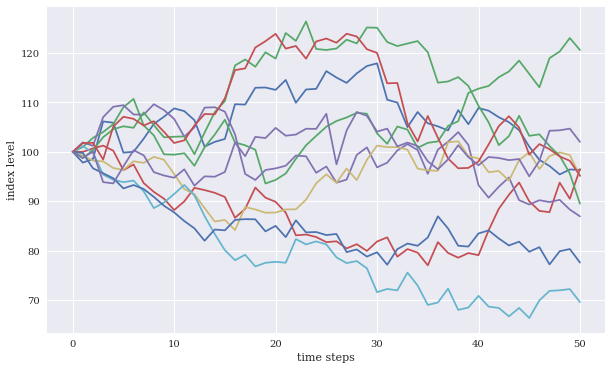

In [8]:
plt.figure(figsize=(10,6))
plt.plot(paths[:, :10])
plt.xlabel('time steps')
plt.ylabel('index level');

*Figure 13-1. Ten simulated paths of geometric Brownian motion*

The main interest is in the distribution of the log returns. To this end, an ndarray object with all the log returns is created based on the simulated paths. Here, a single simulated path and the resulting log returns are shown:

In [9]:
paths[:, 0].round(4)

array([100.    ,  97.821 ,  98.5573, 106.1546, 105.899 ,  99.8363,
       100.0145, 102.6589, 105.6643, 107.1107, 108.7943, 108.2449,
       106.4105, 101.0575, 102.0197, 102.6052, 109.6419, 109.5725,
       112.9766, 113.0225, 112.5476, 114.5585, 109.942 , 112.6271,
       112.7502, 116.3453, 115.0443, 113.9586, 115.8831, 117.3705,
       117.9185, 110.5539, 109.9687, 104.9957, 108.0679, 105.7822,
       105.1585, 104.3304, 108.4387, 105.5963, 108.866 , 108.3284,
       107.0077, 106.0034, 104.3964, 101.0637,  98.3776,  97.135 ,
        95.4254,  96.4271,  96.3386])

In [10]:
log_returns = np.log(paths[1:] / paths[:-1])

In [11]:
log_returns[:, 0].round(4)

array([-0.022 ,  0.0075,  0.0743, -0.0024, -0.059 ,  0.0018,  0.0261,
        0.0289,  0.0136,  0.0156, -0.0051, -0.0171, -0.0516,  0.0095,
        0.0057,  0.0663, -0.0006,  0.0306,  0.0004, -0.0042,  0.0177,
       -0.0411,  0.0241,  0.0011,  0.0314, -0.0112, -0.0095,  0.0167,
        0.0128,  0.0047, -0.0645, -0.0053, -0.0463,  0.0288, -0.0214,
       -0.0059, -0.0079,  0.0386, -0.0266,  0.0305, -0.0049, -0.0123,
       -0.0094, -0.0153, -0.0324, -0.0269, -0.0127, -0.0178,  0.0104,
       -0.0009])

This is something one might experience in financial markets as well: days when one makes a *positive return* on an investment and other days when one is *losing money* relative to the most recent wealth position.

The function print_statistics() is a wrapper function for the scs.describe() function from the scipy.stats subpackage. It mainly generates a better (human-)readable output for such statistics as the mean, the skewness, or the kurtosis of a given (historical or simulated) data set:

In [12]:
def print_statistics(array):
    ''' Prints selected statistics.
    
    Parameters
    ==========
    array: ndarray
        object to generate statistics on
    '''
    sta = scs.describe(array)
    print('%14s %15s' % ('statistic', 'value'))
    print(30 * '-')
    print('%14s %15.5f' % ('size', sta[0]))
    print('%14s %15.5f' % ('min', sta[1][0]))
    print('%14s %15.5f' % ('max', sta[1][1]))
    print('%14s %15.5f' % ('mean', sta[2]))
    print('%14s %15.5f' % ('std', np.sqrt(sta[3])))
    print('%14s %15.5f' % ('skew', sta[4]))
    print('%14s %15.5f' % ('kurtosis', sta[5]))

In [13]:
print_statistics(log_returns.flatten())

     statistic           value
------------------------------
          size  12500000.00000
           min        -0.15664
           max         0.15371
          mean         0.00060
           std         0.02828
          skew         0.00055
      kurtosis         0.00085


In [14]:
# anualized mean log return after correction for the Itô (calculas, stochastics) term
log_returns.mean() * M + 0.5 * sigma ** 2

0.05000000000000006

In [15]:
# anualized volatility; i.e. annualized standard deviation of log returns
log_returns.std() * math.sqrt(M)

0.20000000000000015

The data set in this case consists of 12,500,000 data points with the values mainly lying between +/- 0.15. One would expect annualized values of 0.05 for the mean return (after correcting for the Itô term) and 0.2 for the standard deviation (volatility). The annualized values almost match these values perfectly (multiply the mean value by 50 and correct it for the Itô term; multiply the standard deviation by $\sqrt{50}$). One reason for the good match is the use of moment matching for variance reduction when drawing the random numbers (see "Variance Reduction" on page 372).

Figure 13-2 compares the frequency distribution of the simulated log returns with the probability density function (PDF) of the normal distribution given the parameterizations for r and sigma. The function used is norm.pdf() from the scipy.stats sub-package. There is obviously quite a good fit:

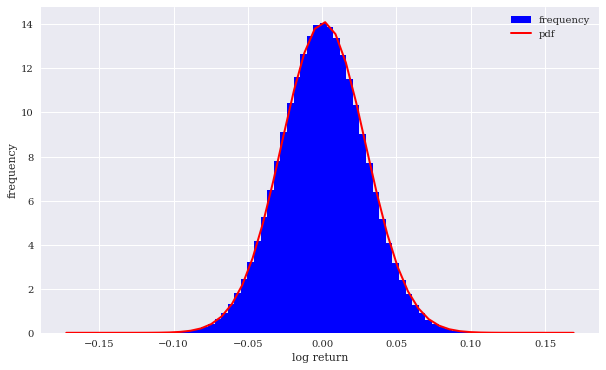

In [16]:
# plots the PDF for the assumed parameters scaled to the interval length
plt.figure(figsize=(10, 6))
plt.hist(log_returns.flatten(), bins=70, density=True, 
        label='frequency', color='b')
plt.xlabel('log return')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, loc=r / M, scale=sigma / np.sqrt(M)), 'r', lw=2.0, label='pdf')
plt.legend();

*Figure 13-2. Histogram of log returns of geometric Brownian motion and normal density function*

Comparing a frequency distribution (histogram) with a theoretical PDF is not the only way to graphically "test" for normality. So-called *quantile-quantile (QQ) plots* are also well suited for this task. Here, sample quantile values are compared to theoretical quantile values. For normally distributed sample data sets, such a plot might look like Figure 13-3, with the absolute majority of the quantile values (dots) lying on a straight line:

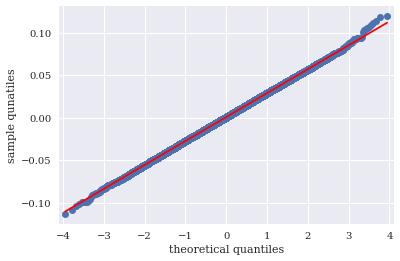

In [17]:
sm.qqplot(log_returns.flatten()[::500], line='s')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample qunatiles');

*Figure 13-3. Quantile-quantile plot for log returns of geometric Brownian motion*

However appealing the graphical approaches might be, they generally cannot replace more rigorous testing procedures. The function normality_test() used in the next example combines three different statistical tests:

*Skewness test* (skewtest())
    
    This tests whether the skew of the sample data is "normal" (i.e., has a value close enough to zero).

*Kurtosis test* (kurtosistest())
    
    Similarly, this tests whether the kurtosis of the sample data is "normal" (again, close enough to zero).

*Normality test* (normaltest())
    
    This combines the other two test approaches to test for normality.
    
The test values indicate that the log returns of the geometric Brownian motion are indeed normally distributed -- i.e., they show *p*-values of 0.05 or above:

In [18]:
def normality_tests(arr):
    ''' Tests for normality distribution of given data set.
    
    Parameters
    ==========
    array: ndarray
        object to generate statistics on
    '''
    print('Skew of data set  %14.3f' % scs.skew(arr))
    print('Skew test p-value %14.3f' % scs.skewtest(arr)[1])
    print('Kurt of data set  %14.3f' % scs.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scs.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scs.normaltest(arr)[1])

In [19]:
# all p-values well above 0.05
normality_tests(log_returns.flatten())

Skew of data set           0.001
Skew test p-value          0.430
Kurt of data set           0.001
Kurt test p-value          0.541
Norm test p-value          0.607


Finally, check whether the end-of-period values are indeed log-normally distributed. This boils down to a normality test, since one only has to transform the data by applying the log function to it to then arrive at normally distributed values (or maybe not). Figure 13-4 plots both the log-normally distributed end-of-period values and the transformed ones ("log index level"):

Text(0.5, 1.0, 'log data')

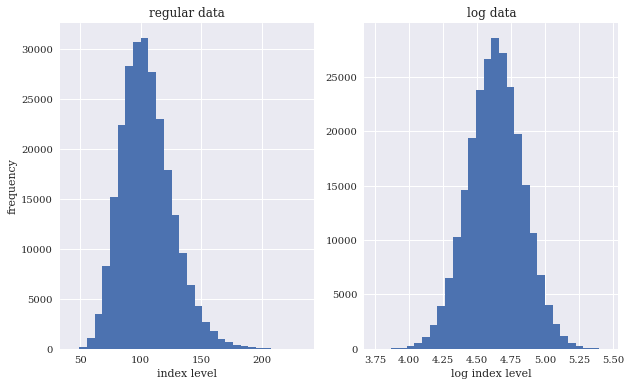

In [20]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.hist(paths[-1], bins=30)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax1.set_title('regular data')
ax2.hist(np.log(paths[-1]), bins=30)
ax2.set_xlabel('log index level')
ax2.set_title('log data')

*Figure 13-4. Hitogram of simulated end-of-period index levels for geometric Brownian motion*

The statistics for the data ste show expected behavior -- for example, a mean value close to 105. The log index level values have skew and kurtosis values close to zero and they show high *p*-values, providing strong support for the normal distribution hypothesis:

In [21]:
print_statistics(paths[-1])

     statistic           value
------------------------------
          size    250000.00000
           min        42.74870
           max       233.58435
          mean       105.12645
           std        21.23174
          skew         0.61116
      kurtosis         0.65182


In [22]:
print_statistics(np.log(paths[-1]))

     statistic           value
------------------------------
          size    250000.00000
           min         3.75534
           max         5.45354
          mean         4.63517
           std         0.19998
          skew        -0.00092
      kurtosis        -0.00327


In [23]:
normality_tests(np.log(paths[-1]))

Skew of data set          -0.001
Skew test p-value          0.851
Kurt of data set          -0.003
Kurt test p-value          0.744
Norm test p-value          0.931


Figure 13-5 compares again the frequency distribution with the PDF of the normal distribution, showing a pretty good fit (as now is, of course, to be expected):

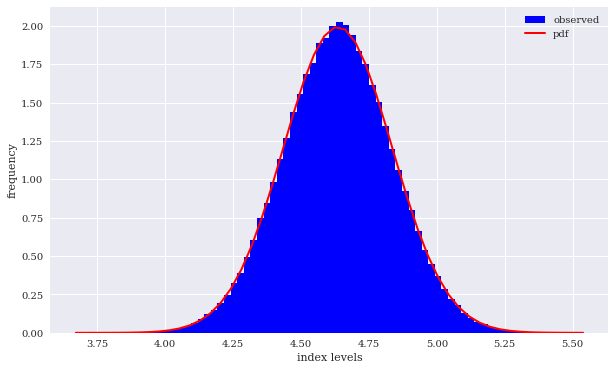

In [24]:
plt.figure(figsize=(10, 6))
log_data = np.log(paths[-1])
plt.hist(log_data, bins=70, density=True,
        label='observed', color='b')
plt.xlabel('index levels')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, log_data.mean(), log_data.std()), 'r', lw=2.0, label='pdf')
plt.legend();

*Figure 13-5. Histogram of log index levels of geometric Brownian motion and normal density function*

Function 13-6 also supports the hypothesis that the log index levels are normally distributed:

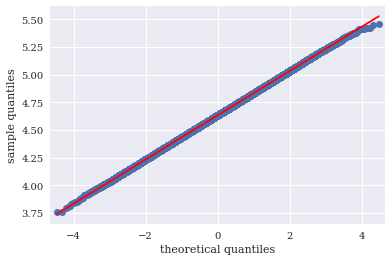

In [25]:
sm.qqplot(log_data, line='s')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles');

*Figure 13-6. Quantile-quantile plot for log index levels of geometric Brownian motion*

The normality assumption with regard to the uncertain returns of financial instruments is central to a number of financial theories. Python provides efficient statistical and graphical means to test whether time series data is normally distributed or not.

## Real-World Data
This section analyzes four historical financial time series, two for technology stocks and two for exchange traded funds (ETFs):

- APPL.0: Apple Inc. stock price
- MSFT.0: Microsoft Inc. stock price
- SPY: SPDR S&P 500 ETF Trust
- GLD: SPDR Gold Trust

The data management tool of choice is pandas (see Chapter 8). Figure 13-7 shows the normalized prices over time:

In [26]:
# fetch the yahoo api from previous chapters
from datetime import datetime
import pandas_datareader.data as wb
import pandas_datareader.iex as iex
import pandas as pd
import numpy as np

In [27]:
instruments = ['Apple Stock', 'Microsoft Stock', 'SPDR S&P 500 ETF Trust', 'SPDR Gold Trust']
stocks = ['AAPL', 'MSFT','SPY', 'GLD']

In [28]:
start_date = datetime(2010,1,4)
end_date = datetime(2018,6,29)

In [29]:
tick_data = wb.DataReader(stocks, 'yahoo', start_date, end_date)
eod = tick_data['Adj Close']
for ric, name in zip(eod.columns, instruments):
    print('{:8s} | {}'.format(ric, name))

AAPL     | Apple Stock
MSFT     | Microsoft Stock
SPY      | SPDR S&P 500 ETF Trust
GLD      | SPDR Gold Trust


In [30]:
eod = eod.dropna()
eod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2138 non-null   float64
 1   MSFT    2138 non-null   float64
 2   SPY     2138 non-null   float64
 3   GLD     2138 non-null   float64
dtypes: float64(4)
memory usage: 83.5 KB


In [31]:
eod.head()

Symbols,AAPL,MSFT,SPY,GLD
Date,,,,
2010-01-04,6.535086,23.800220,89.225395,109.800003
2010-01-05,6.546385,23.807917,89.461586,109.699997
2010-01-06,6.442253,23.661806,89.524582,111.510002
2010-01-07,6.430345,23.415726,89.902504,110.820000
2010-01-08,6.473096,23.577217,90.201691,111.370003


<AxesSubplot:xlabel='Date'>

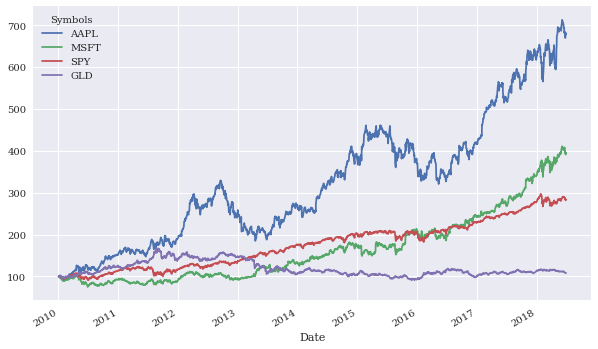

In [32]:
(eod / eod.iloc[0] * 100).plot(figsize=(10, 6))

*Figure 13-7. Normalized prices of financial instruments over time*

Figure 13-8 shows the log returns of the financial instruments as histograms:

In [33]:
log_returns = np.log(eod / eod.shift(1))
log_returns.head()

Symbols,AAPL,MSFT,SPY,GLD
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.001728,0.000323,0.002644,-0.000911
2010-01-06,-0.016035,-0.006156,0.000704,0.016365
2010-01-07,-0.001850,-0.010454,0.004213,-0.006207
2010-01-08,0.006626,0.006873,0.003322,0.004951


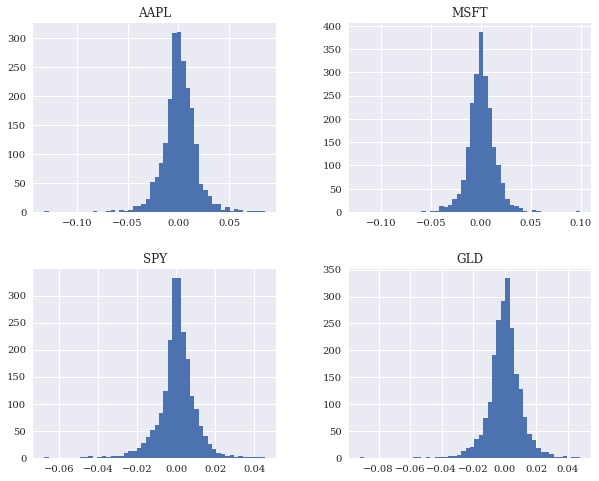

In [34]:
log_returns.hist(bins=50, figsize=(10, 8));

*Figure 13-8. Histograms of log returns for financial instruments*

As a next step, consider the different statistics for the time series data sets. The kurtosis values seem to be especially far from normal for all four data sets:

In [35]:
# statistics for time series of financial instruments
for stock in stocks:
    print('\nResults for symbol {}'.format(stock))
    print(30 * '-')
    log_data = np.array(log_returns[stock].dropna())
    print_statistics(log_data)


Results for symbol AAPL
------------------------------
     statistic           value
------------------------------
          size      2137.00000
           min        -0.13188
           max         0.08502
          mean         0.00090
           std         0.01590
          skew        -0.23852
      kurtosis         4.80463

Results for symbol MSFT
------------------------------
     statistic           value
------------------------------
          size      2137.00000
           min        -0.12103
           max         0.09941
          mean         0.00064
           std         0.01420
          skew        -0.09469
      kurtosis         7.32470

Results for symbol SPY
------------------------------
     statistic           value
------------------------------
          size      2137.00000
           min        -0.06734
           max         0.04545
          mean         0.00049
           std         0.00930
          skew        -0.53618
      kurtosis         4.59

Figure 13-9 shows the QQ plot for the SPY ETF. Obviously, the sample quantile values do ont lie on a straight line, indicating "non-normality". On the left and right sides there are many values that lie well below the line and well above the line, respectively. In other words, the time series data exhibits *fat tails*. This term refers to a (frequency) distribution where large negative and positive values are observed more often than a normal distribution would imply. The same conclusions can be drawn from Figure 13-10, which presents the data for the Microsoft stock. There also seems to be evidence for a fat-tailed distribution:

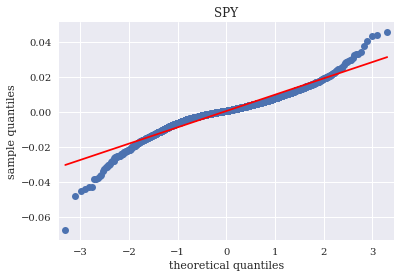

In [36]:
sm.qqplot(log_returns['SPY'].dropna(), line='s')
plt.title('SPY')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles');

*Figure 13-9. Quantile-quantile plot for SPY log returns*

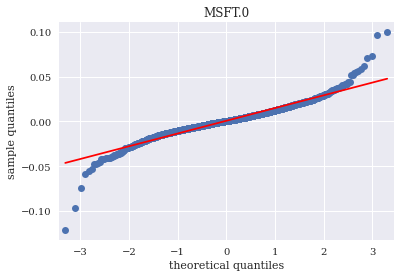

In [37]:
sm.qqplot(log_returns['MSFT'].dropna(), line='s')
plt.title('MSFT.0')
plt.xlabel('theoretical quantiles')
plt.ylabel('sample quantiles');

*Figure 13-10. Quantile-quantile plot for MSFT log returns*

This leads to the statistical normality tests:

In [38]:
# normality test results for the time series of financial instruments
for stock in stocks:
    print('\nResults for symbol {}'.format(stock))
    print(32 * '-')
    log_data = np.array(log_returns[stock].dropna())
    normality_tests(log_data)


Results for symbol AAPL
--------------------------------
Skew of data set          -0.239
Skew test p-value          0.000
Kurt of data set           4.805
Kurt test p-value          0.000
Norm test p-value          0.000

Results for symbol MSFT
--------------------------------
Skew of data set          -0.095
Skew test p-value          0.074
Kurt of data set           7.325
Kurt test p-value          0.000
Norm test p-value          0.000

Results for symbol SPY
--------------------------------
Skew of data set          -0.536
Skew test p-value          0.000
Kurt of data set           4.598
Kurt test p-value          0.000
Norm test p-value          0.000

Results for symbol GLD
--------------------------------
Skew of data set          -0.599
Skew test p-value          0.000
Kurt of data set           5.687
Kurt test p-value          0.000
Norm test p-value          0.000


The *p*-values of the different tests are all zero, *strongly rejecting the test hypothesis* that the different sample data sers are normally distributed. This shows that the normal assumption for stock market returns and other asset classes -- as, for example, embodied in the geometric Brownian motion model -- cannot be justified in general and that one might have to use richer models that are able to generate fat tails (e.g., jump diffusion models or models with stochastic volatility).

## Portfolio Optimization
Modern or mean-variance portfolio theory is a major cornerstone of financial theory. Based on this theoretical breakthrough the Nobel Prize in Economics was awarded to its inventor, Harry Markowitz, in 1990. Although formulated in the 1950s, it is still a thoery taught to finance students and applied in practice today (often with some minor or major modifications). This section illustrates the fundamental principles of the theory.

Chapter 5 in the book by Copeland, Weston, and Shastri (2005) provides an introduction to the formal topics associated with MPT. As pointed out previously, the assumption of normally distributed returns is fundamental to the theory:

    By looking only at mean variance, we are necessarily assuming that no other statistics are necessary to describe the distribution of end-of-period welth. Unless investors have a special type of utility function (quadratic utility function), it is necessary to assume that returns have a normal distribution, which can be completely described by mean and variance.

### The Data
The analysis and examples that follow use the same financial instruments as before. The basic idea of MPT is to make use of *diversification* to achieve a minimal portfolio risk given a target return level or a maximum portfolio return given a certain level of risk. One would expect such diversification effects for the right combination of a larger number of assets and a ceratin diversity in the assets. However, to convey the basic ideas and show typical effects, four financial instruments shall suffice. Figure 13-11 shows the frequency distribution of the log returns for all financial instruments:

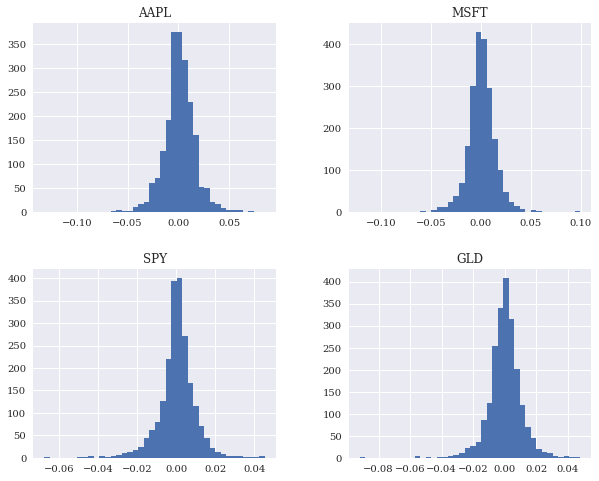

In [39]:
noa = len(stocks)
rets = np.log(eod / eod.shift(1))
rets.hist(bins=40, figsize=(10, 8));

*Figure 13-11. Histograms of log returns of financial instruments*

### The Basic Theory
In what follows, it is assumed that an investor is not allowed to set up short positions in a financial instrument. Only long positions are allowed, which implies that 100% of the investor's wealth has to be divided among the available instruments in such a way that all positions are long (positive) *and* that the positions add up to 100%. Given the four instruments, one could, for example, invest equal amounts into every such instrument -- i.e., 25% of the available wealth in each. The following code generates four uniformly distributed random numbers between 0 and 1 and then normalizes the values such that the sum of all values equals 1:

In [40]:
# random portfolio weights
weights = np.random.random(noa)
# normalized to 100% (1)
weights /= np.sum(weights)

In [41]:
weights

array([0.07650728, 0.06021919, 0.63364218, 0.22963135])

In [42]:
weights.sum()

1.0

As verified here, the weights add up to 1; i.e., $\Sigma_I w_i = 1$, where *I* is the number of financial instruments and $w_i > 0$ is the weight of financial instrument *i*. Equation 13-1 provides the formula for the *expected portfolio return* given the weights for the single instruments. This is an *expected* portfolio return in the sense that historical mean performance is assumed to be the best estimator for future (expected) performance. Here, the *r_i* are the state-dependent future returns (vector with return values assumed to be normally distributed) adn $\mu_i$ is the expected return for the instrument *i*. Finally, $w^T$ is the transpose of the weights vector and $\mu$ is the vector of the expected security returns.

*Equation 13-1. General formula for expected portfolio return* 

$\mu_p = E(\sum\limits_{I} w_i r_i)$ 

$= \sum\limits_{I} w_i E(r_i)$

$= \sum\limits_{I} w_i \mu_i$

$= w^{T}\mu$

In [43]:
# translation into python, including annualization
np.sum(rets.mean() * weights) * 252

0.10715883802834657

The second object of importance in MPT is the *expected portfolio variance*. The covariance between two securities is defined by $\sigma_{ij} = \sigma_{ji} = E(r_i - \mu_i)(r_j - \mu_j)$. The variance of a security is the special case of teh covariance with itself: $\sigma^2_{i} = E(r_i - \mu_i)^2)$. Equation 13-2 provides the covariance matrix for a portfolio of securities (assuming an equal weight of 1 for every secutiry).

Equipped with the portfolio covariance matrix, Equation 13-2 then provides the formula for the expected portfolio variance.

*Equation 13-2. General formula for expected portfolio variance*

$\sigma^2_p = E((r - \mu)^2)$

$= \sum\limits_{i \in I} \sum\limits_{j \in I} w_i w_j \sigma_{ij}$

$= w^T \Sigma w$

In python, this all again boils down to a single line of code, making heavy use of NumPy vectorization capabilities. The np.dot() function gives the dot product of two vectors/matricies. The T attribute or transpose() method gives the transpose of a vector or matrix. Given the portfolio variance, the (expected) portfolio standard deviation or volatility $\sigma_P = \sqrt{\sigma^2_P}$ is then only one square root away:

In [44]:
# Annualized portfolio variance given the portfolio weights
np.dot(weights.T, np.dot(rets.cov() * 252, weights))

0.014714280416547392

In [45]:
# Annualized portfolio volatility given the portfolio weights
math.sqrt(np.dot(weights.T, np.dot(rets.cov() * 252, weights)))

0.12130243367940889

**Python & Vectorization**

The MPT example shows how efficient it is with Python to translate mathematical concepts, like portfolio return or variance, into executable, vectorized code (an argument made in Chapter 1).

This mainly completes the tool set for mean-variance portfolio selection. Of paramount interest to investors is what risk-return profiles are possible for a given set of financial instruments, and their statistical characteristics. To this end, the following implements a Monte Carlo simulation (see Chapter 12) to generate random portfolio weight vectors on a larger scale. For every simulated allocation, the code records the resulting expected portfolio return and variance. To simplify the code, two functions, port_ret() and port_vol(), are defined:

In [46]:
def port_ret(weights):
    return np.sum(rets.mean() * weights) * 252

In [47]:
def port_vol(weights):
    return np.sqrt(np.dot(weights.T, np.dot(rets.cov() * 252, weights)))

In [48]:
prets = []
pvols = []
# Monte Carlo simulation of portfolio weights
for p in range (2500):
    weights = np.random.random(noa)
    weights /= np.sum(weights)
    # collect statistics in list
    prets.append(port_ret(weights))
    pvols.append(port_vol(weights))
prets = np.array(prets)
pvols = np.array(pvols)

Figure 13-13 illustrates the results of the Monte Carlo simulation. In addition, it provides results for the Sharpe ratio, defined as $SR \equiv \frac{\mu_P - r_f}{\sigma_P}$ -- i.e., the expected excess return of the portfolio over the risk-free short rate $r_f$ divided by the expected standard deviation of the portfolio. For simplicity, $r_f \equiv 0$ is assumed:

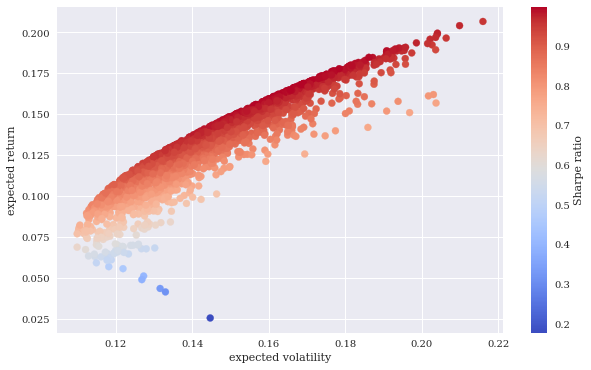

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols, prets, c=prets / pvols, marker='o', cmap='coolwarm')
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio');

*Figure 13-13. Expected return and volatility for random portfolio weights*

It is clear by inspection of Figure 13-13 that not all weight distributions perform well when measured in terms of mean and volatiliity. For example, for a fixed risk level of, say, 15% there are multiple portfolios that all show different returns. As an investor, one is generally interested in the maximum return given a fixed risk level or the minimum risk given a fixed return expectation. This set of portfolios then makes up the so-called *efficient frontier*. This is derived later in this section.

## Optimal Portfolios
This *minimization* function is quite general and allows for equality constratints, inequality constraints, and numerical bounds for the parameters.

First, the *maximization of the Sharpe ratio.* Formally, the negative value of the Sharpe ratio is minimized to derive at the maximum value and the optimal portfolio compostition. The constraint is that all parameters (weights) add up to 1. This can be formulated as follows using the conventions of the minimize() [function](http://bit.ly/using_minimize). The parameter values (weights) are also bound to be between 0 and 1. These values are provided to the minimization function as a tuple of tuples.

The only input that is missing for a call of the optimization function is a starting parameter list (initial guess for the weights vector). An equal distribution of weights will do:

In [50]:
import scipy.optimize as sco

In [51]:
# function to be minimized
def min_func_sharpe(weights):
    return port_ret(weights) / port_vol(weights)

In [52]:
# equality constraint
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

In [53]:
# bounds for the parameters
bnds = tuple((0, 1) for x in range(noa))

In [54]:
# equal weights vector
eweights = np.array(noa * [1. / noa,])
eweights

array([0.25, 0.25, 0.25, 0.25])

In [55]:
min_func_sharpe(eweights)

0.952830674953268

Calling the function returns more than just the optimal parameter values. The results are stored in an object called opts. The main interest lies in getting the optimal portfolio composition. To this end, one can access the results object by providing the key of interest; i.e., x in this case:

In [56]:
%%time
# the optimization (i.e., minimization of function min_func_sharpe())
opts = sco.minimize(min_func_sharpe, eweights, 
                   method='SLSQP', bounds=bnds,
                   constraints=cons)

CPU times: user 28.2 ms, sys: 2.55 ms, total: 30.7 ms
Wall time: 37.1 ms


In [57]:
# results of the optimization
opts

     fun: 0.05647214873544352
     jac: array([ 1.3940415 ,  1.00282209,  0.76013158, -0.        ])
 message: 'Optimization terminated successfully'
    nfev: 15
     nit: 3
    njev: 3
  status: 0
 success: True
       x: array([0., 0., 0., 1.])

In [58]:
# optimal portfolio weights
opts['x'].round(3)

array([0., 0., 0., 1.])

In [59]:
# resulting portfolio return
port_ret(opts['x']).round(3)

0.009

In [60]:
# resulting portfolio volatility
port_vol(opts['x']).round(3)

0.162

In [61]:
# maximum Sharpe ratio
port_ret(opts['x']) / port_vol(opts['x'])

0.05647214873544352

Next, the *minimization of the variance* of the portfolio. This is the same as minimizing the volatility:

In [62]:
# the minimization of the portfolio volatility
optv = sco.minimize(port_vol, eweights, method='SLSQP', bounds=bnds, constraints=cons)

In [63]:
optv

     fun: 0.10933985698744675
     jac: array([0.11099676, 0.1093836 , 0.1093165 , 0.10936793])
 message: 'Optimization terminated successfully'
    nfev: 45
     nit: 9
    njev: 9
  status: 0
 success: True
       x: array([3.25260652e-19, 3.99392956e-05, 5.45840001e-01, 4.54120060e-01])

In [64]:
optv['x'].round(3)

array([0.   , 0.   , 0.546, 0.454])

In [65]:
port_vol(optv['x']).round(3)

0.109

In [66]:
port_ret(optv['x']).round(3)

0.071

In [67]:
port_ret(optv['x']) / port_vol(optv['x'])

0.6524534291270017

This time, the portfolio is made up of only three financial instruments. This portfolio mix leads to teh so-called *minimum volatility* or *minimum variance portfolio*.

## Efficient Frontier
The derivation of all optimal portfolios -- i.e., all portfolios with the minimum volatility for a given target return level (or all portfolios with maximum return for a given risk level) -- is similar to the previous optimizations. The only difference is that one has to iterate over multiple starting conditions. 

The approach taken is to fix a target return level and to derive for each such level those portfolio weights that lead to the minimum volatility value. For the optimization, this leads to two conditions: one for the target return level, tret, and one for the sum of the portfolio weights as before. The boundary values for each parameter stay the same. When iterating over different target return levels (trets), one condition for the minimization changes. That is why  the constraints dictionary is updated during every loop:

In [68]:
# binding constraints for the efficient frontier
cons = ({'type': 'eq', 'fun': lambda x: port_ret(x) - tret}, 
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

In [69]:
bnds = tuple((0, 1) for x in weights)

In [70]:
%%time
trets = np.linspace(0.05, 0.2, 50)
tvols = []
for tret in trets:
    # minimization of the portfolio
    res = sco.minimize(port_vol, eweights, method='SLSQP', bounds=bnds, constraints=cons)
    tvols.append(res['fun'])
tvols = np.array(tvols)

CPU times: user 2.79 s, sys: 64.6 ms, total: 2.86 s
Wall time: 3.53 s


Figure 13-4 shows the optimization results. The thick line indicates the optimal portfolios given a certain target return; the dots are, as before, the random portfolios. In addition, the figure shows two larger stars, one for the minimum volatility/variance portfolio (the leftmost portfolio) and one for the portfolio with the maximum Sharpe ratio:

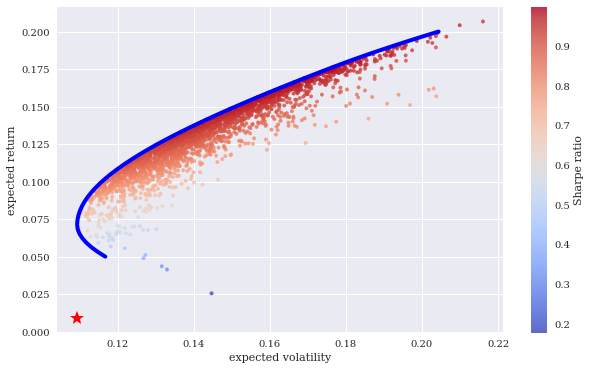

In [71]:
plt.figure(figsize=(10,6))
plt.scatter(pvols, prets, c=prets / pvols, marker='.', alpha=0.8, cmap='coolwarm')
plt.plot(tvols, trets, 'b', lw=4.0)
plt.plot(port_vol(optv['x']), port_ret(opts['x']), 'r*', markersize=15.0)
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio')

*Figure 13-14. Minimum risk portfolios for given return levels (efficient frontier)*

The *efficient frontier* is comprised of all optimal portfolios with a higher return than the absolute minimum variance portfolio. These portfolios dominate all other portfolios in terms of expected returns given a certain risk level. 

## Capital Market Line
In addition to risky financial instruments like stocks or commodities (such as gold), there is in general one universal, riskless investment opportunity available: *cash* or *cash accounts*. In an idealized world, money held in a cash accout with a large bank can be considered riskless (e.g., through public deposit insurance schemes). The downside is that such a riskless investment generally yields only a small return, sometimes close to zero.

However, taking into account such a riskless asset enhances the efficient investment opportunity set for investors considerably. The basic idea is that investors first determine an efficient portfolio of risky assets and then add the riskless asset to the mix. By adjustingthe proportion of the investor's wealth to be invested in the riskless asset it is possible to achieve any risk-return profile that lies on the straight line (in the risk-return space) between the riskless asset and the efficient portfolio.

Which efficient portfolio (out of many options) is to be taken to invest in optimally? It is the one portfolio where the tangent line of the efficient frontier goes exactly through the risk-return point of the riskless portfolio. For example, consider a riskless interest rate of $r_f = 0.01$. The portfolio is to be found on the efficient frontier for which the tangent goes through the point $(\sigma_f$, $r_f) = (0, 0.01)$ in the risk-return space.

For the calculations that follow, a functional approximation and the first derivative for the efficient frontier are used. Cubic splines interpolation provides such a differentiable functional approximation (see Chapter 11). For the spline interpolation, only those portfolios from the efficient frontier are used. Via this numerical approach it is possible to define a continuously differentiable function f(x) for the efficient frontier and the respective first derivative function df(x):

In [72]:
import scipy.interpolate as sci

In [73]:
# index position of minimum volatility portfolio
ind = np.argmin(tvols)
# relevant portfolio volatility and return values
evols = tvols[ind:]
erets = trets[ind:]

In [74]:
# cubic splines interpolation on these values
tck = sci.splrep(evols, erets)

In [75]:
def f(x):
    ''' Efficient frontier function (splines approximation). '''
    return sci.splev(x, tck, der=0)

def df(x):
    ''' First derivative of efficient frontier function '''
    return sci.splev(x, tck, der=1)

What is now to be derived is a linear function $t(x) = a+b \cdot x$ representing the line that passes through the riskless asset in risk-return space and that is tangent to the efficient frontier. Equation 13-3 describes all three conditions that the function $t(x)$ needs to satisfy.

*Equation 13-3. Mathematical conditions for capital market line*

$t(x) = a+b \cdot x$

$t(0) = r_f \Leftrightarrow a = r_f$

$t(x) = f(x) \Leftrightarrow a+b\cdot x = f(x)$

$t(x) = f(x) \Leftrightarrow b = f(x)$

Since there is no closed formula for the efficient frontier or the first derivative of it, one has to solve the system of equations in Equation 13-3 numerically. To this end, define a Python function that returns the values of all three equations given the parameter set $p = (a,b,x)$:

The function sco.fsolve() from scipy.optimize is capable of solving such a system of equations. In addition to the function equations(), an initial parameterization is provided. Note that success or failure of the optimization might depend on the initial parameterization, which therefore has to be chosen carefully -- generally by a combination of educated guesses with trial and error:

In [76]:
def equations(p, rf=0.01):
    # equation for capital market line (CML)
    eq1 = rf - p[0]
    eq2 = rf + p[1] * p[2] - f(p[2])
    eq3 = p[1] - df(p[2])
    return eq1, eq2, eq3

In [77]:
# solving these equations for given initial values
opt = sco.fsolve(equations, [0.01, 0.5, 0.15])

In [78]:
# the optimal parameter values
opt

array([0.01      , 0.94187814, 0.17923899])

In [79]:
# the equation values are all zero
np.round(equations(opt), 6)

array([ 0., -0.,  0.])

Figure 13-15 presents the results graphically; the star represents the optimal portfolio from the efficient frontier for which the tangent line passes through the riskless asset point (0, $r_f=0.01$):

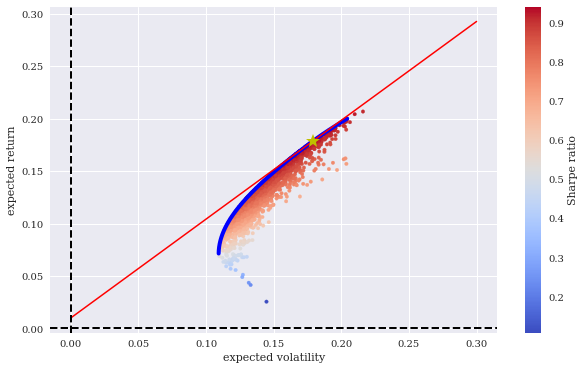

In [80]:
plt.figure(figsize=(10, 6))
plt.scatter(pvols, prets, c=(prets - 0.01) / pvols, marker='.', cmap='coolwarm')
plt.plot(evols, erets, 'b', lw=4.0)
cx = np.linspace(0.0, 0.3)
plt.plot(cx, opt[0] + opt[1] * cx, 'r', lw=1.5)
plt.plot(opt[2], f(opt[2]), 'y*', markersize=15.0)
plt.grid(True)
plt.axhline(0, color='k', ls='--', lw=2.0)
plt.axvline(0, color='k', ls='--', lw=2.0)
plt.xlabel('expected volatility')
plt.ylabel('expected return')
plt.colorbar(label='Sharpe ratio')

*Figure 13-15. Capital market line and tangent portfolio (star) for risk-free rate of 1%*

The portfolio weights of the optimal (tangent) portfolio are as follows. Only three of the four assets are in the mix:

In [81]:
# binding contraints for the tangent portfolio (gold star in Figure 13-15)
cons = ({'type': 'eq', 'fun': lambda x: port_ret(x) - f(opt[2])},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

res = sco.minimize(port_vol, eweights, method='SLSQP', bounds=bnds, constraints=cons)

In [82]:
# given portfolio weights
res['x'].round(3)

array([0.46 , 0.214, 0.327, 0.   ])

In [83]:
port_ret(res['x'])

0.17882128281751583

In [84]:
port_vol(res['x'])

0.17923931054989461

In [85]:
port_ret(res['x']) / port_vol(res['x'])

0.9976677675723238

## Bayesian Statistics
Bayesian statistics nowadays is widely popular in empirical finance. This chapter can for sure not lay the foundations for all concepts of the field. The reader should therefore consult, if needed, a textbook like the one by Geweke (2005) for a general introduction or Rachev (2008) for one that is financially motivated.

### Bayes' Formula
The most common interpretation of Bayes' formula in finance is the *diachronic interpretation*. This mainly states that over time one learns new information about certain variables or parameters of interest, like the mean return of a time series. Equation 13-4 states the theorem formally.

*Equation 13-4. Bayes' formula*

$p(H | D) = \frac{p(H) \cdot p(D | H)}{p(D)}$

Here, $H$ stands for an event, the hypothesis, and $D$ represents the data an experiment or the real world might present. On the basis of these fundamental notions, one has:

$p(H)$ : The *prior* probability

$p(D)$ : The probability for the data under any hypothesis, called the *normalizing constant*

$p(D|H)$ : The *likelihood* (i.e., the probability) of the data under hypothesis *H*

$p(H|D)$ : The *posterior* probability; i.e., after one has seen the data

Consider a simple example. There are two boxes, $B_1$ and $B_2$. Box $B_1$ contains 30 black balls and 60 red balls, while box $B_2$ contains 60 black balls and 30 red balls. A ball is randomly drawn from one of the two boxes. Assume the ball is *black*. What are the probabilities for the hypothesis "$H_1$: Ball is from box $B_1$"; and "$H_2$: Ball is from box $B_2$", respectively?

Before the random draw of the ball, both hypotheses are equally likely. After it is clear that the ball is black, one has to update the probability for both hypotheses according to Bayes' formula. Consider hypothesis $H_1$:

- *$Prior: p(H_1) = \frac{1}{2}$*
- *$Normalizing constant: p(D) = \frac{1}{2} \cdot \frac{1}{3} + \frac{1}{2} \cdot \frac{2}{3} = \frac{1}{2}$*
- *$Likelihood: p(D|H) = \frac{1}{3}$*

This gives the updated probability for $H_1$ of $p(H_1|D) = \frac{\frac{1}{2} \cdot \frac{1}{3}}{\frac{1}{2}} = \frac{1}{3}$.

This result also makes sense intuitively. The probability of drawing a black ball from box $B_2$ is twice as high as that of the same event happening with box $B_1$. Therefore, having drawn a black ball, the hypothesis $H_2$ has with $p(H_2|D) = \frac{2}{3}$ an updated probability two times as high as the updated probability for hypothesis $H_1$.

## Bayesian Regression
With PyMC3 the Python ecosystem provides a comprehensive package to technically implement Bayesian statistics and probabilistic programming.

Consider the following example based on noisy data around a straight line. First, a linear ordinary least-squares regression (see Chapter 11) is implemented on the data set, the result of which is visualized in Figure 13-16:

In [86]:
import numpy as np
import pandas as pd
import datetime as dt
from pylab import mpl, plt

In [87]:
plt.style.use('seaborn')
mpl.rcParams['font.family'] = 'serif'
np.random.seed(1000)
%matplotlib inline

In [88]:
x = np.linspace(0, 10, 500)
y = 4 + 2 * x + np.random.standard_normal(len(x)) * 2

In [89]:
reg = np.polyfit(x, y, 1)

In [90]:
reg

array([2.03384161, 3.77649234])

Text(0, 0.5, 'y')

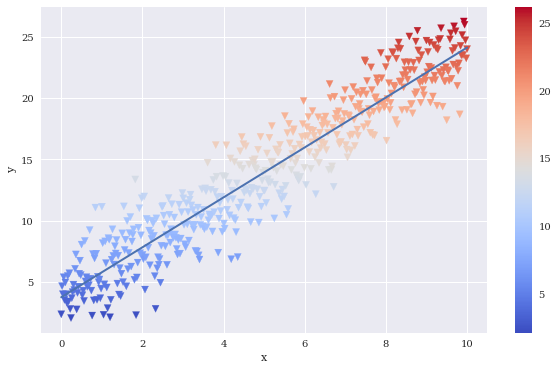

In [91]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=y, marker='v', cmap='coolwarm')
plt.plot(x, reg[1] + reg[0] * x, lw=2.0)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')

*Figure 13-16. Sample data points and regression line*

The results of the OLS regression approach are fixed values for the two parameters of the regression line (intercept and slope). Note that the highest-order monomial factor (in this case, the slope of the regression line) is at index level 0 and that the intercept is at index level 1. The original parameters 2 and 4 are not perfectly recovered, but this of course is due to the noise included in the data.

Second, a Bayesian regression making use of the PyMC3 package. Here, it is assumed that the parameters are distributed in a certain way. For example, consider the equation describing the regression line $\hat{y}(x) = \alpha + \beta \cdot x$. Assume now the following *priors:*

- $\alpha$ is normally distributed with mean 0 and a standard deviation of 20.
- $\beta$ is normally distributed with mean 0 and a standard deviation of 10.

For the *likelihood*, assume a normal distribution with a mean of $\hat{y}(x)$ and a uniformly distributed standard deviation of between 0 and 10.

A major element of Bayesian regression is [*Markov chain Monte Carlo (MCMC) sampling*](https://en.wikipedia.org/wiki/Markov_chain_Monte_Carlo). In principle, this is the same as drawing balls multiple times from boxes, as in the simples example in the previous section -- just in a more systematic, automated way.

For the technical sampling, there are three different functions to call:

- **find_MAP()** finds the starting point for the sampling algorithm by deriving the *local maximum a posteriori point*.
- **NUTS()** implements the so-called "efficient No-U-Turn Sampler with dual averaging" (NUTS) algorithm for MCMC sampling given the assumed priors.
- **sample()** draws a number of samples given the starting value from find_MAP() and the optimal step size from the NUTS algorithm

All this is to be wrapped into a PyMC3 Model object and executed within a with statement:

In [92]:
import pymc3 as pm

In [93]:
%%time
with pm.Model() as model:
    # model
    alpha = pm.Normal('alpha', mu=0, sd=20)
    beta = pm.Normal('beta', mu=0, sd=10)
    sigma = pm.Uniform('sigma', lower=0, upper=10)
    y_est = alpha + beta * x
    likelihood = pm.Normal('y', mu=y_est, sd=sigma, observed=y)
    
    # inference
    start = pm.find_MAP()
    step = pm.NUTS()
    trace = pm.sample(100, tune=1000, start=start, progressbar=True, return_inferencedata=True)

Only 100 samples in chain.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, beta, alpha]


Sampling 2 chains for 1_000 tune and 100 draw iterations (2_000 + 200 draws total) took 20 seconds.


CPU times: user 6.32 s, sys: 799 ms, total: 7.12 s
Wall time: 35.2 s


In [94]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.767,0.183,3.486,4.110,0.016,0.011,136.0,134.0,1.0
beta,2.035,0.030,1.980,2.082,0.003,0.002,129.0,134.0,1.0
sigma,2.015,0.068,1.917,2.166,0.006,0.004,132.0,106.0,1.0


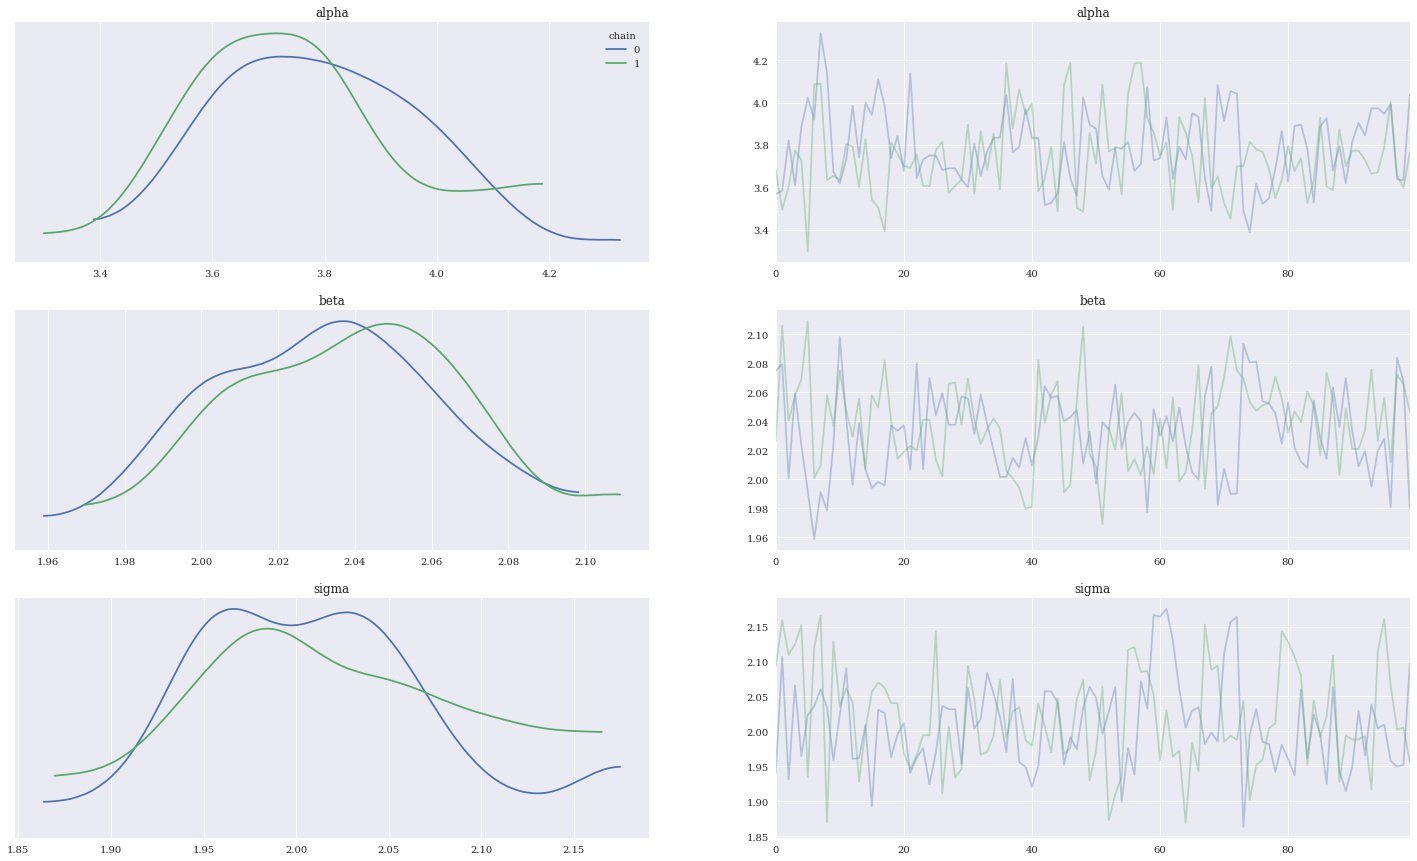

In [95]:
pm.plot_trace(trace, compact=False, legend=True, figsize=(25,15));